<a href="https://colab.research.google.com/github/Loknath73/Language-Detection-Model/blob/main/Language_Detection_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

Saving language_with_bengali.csv to language_with_bengali.csv


In [3]:
import pandas as pd
import io


df = pd.read_csv(io.BytesIO(uploaded['language_with_bengali.csv']))
df.head()

,Text,language
0,klement gottwaldi surnukeha palsameeriti ning ...,Estonian
1,sebes joseph pereira thomas på eng the jesuit...,Swedish
2,ถนนเจริญกรุง อักษรโรมัน thanon charoen krung เ...,Thai
3,விசாகப்பட்டினம் தமிழ்ச்சங்கத்தை இந்துப் பத்திர...,Tamil
4,de spons behoort tot het geslacht haliclona en...,Dutch


In [4]:

print(df.columns)

Index(['Text', 'language'], dtype='object')


In [5]:
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix


def clean_text(text):
    text = re.sub(r'[!@#$(),\n"%^*?\:;~`0-9]', ' ', text)
    text = re.sub(r'\[\]', ' ', text)
    text = text.lower()
    return text

df['cleaned_text'] = df['Text'].apply(clean_text)

X = df['cleaned_text']
y = df['language']

cv = CountVectorizer()
X_vectors = cv.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X_vectors, y, test_size=0.2, random_state=42)


model = MultinomialNB()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 93.85%


In [6]:
cv = CountVectorizer(analyzer='char_wb', ngram_range=(1, 3))

X_vectors = cv.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_vectors, y, test_size=0.2, random_state=42)

In [7]:

model = MultinomialNB()


model.fit(X_train, y_train)


y_pred = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 97.67%


In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay



In [9]:
import pandas as pd
import re
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
import joblib

print("⏳ Training with the corrected dataset (now includes real Bengali rows)...")


df = pd.read_csv('language_with_bengali.csv')




balanced_df = df

def clean_text(text):
    text = re.sub(r'[!@#$(),\n"%^*?\:;~`0-9]', ' ', str(text))
    text = text.lower()
    return text

balanced_df['cleaned_text'] = balanced_df['Text'].apply(clean_text)

X = balanced_df['cleaned_text']
y = balanced_df['language']


cv = CountVectorizer(analyzer='char_wb', ngram_range=(1, 3))
X_vectorized = cv.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_vectorized, y, test_size=0.2, random_state=42)

model = MultinomialNB()
model.fit(X_train, y_train)


joblib.dump(model, 'language_detector_model.pkl')
joblib.dump(cv, 'vectorizer.pkl')

print("✅ Success! Balanced model updated. Try running your test code now!")

⏳ Training with the corrected dataset (now includes real Bengali rows)...
✅ Success! Balanced model updated. Try running your test code now!


Generating Confusion Matrix...


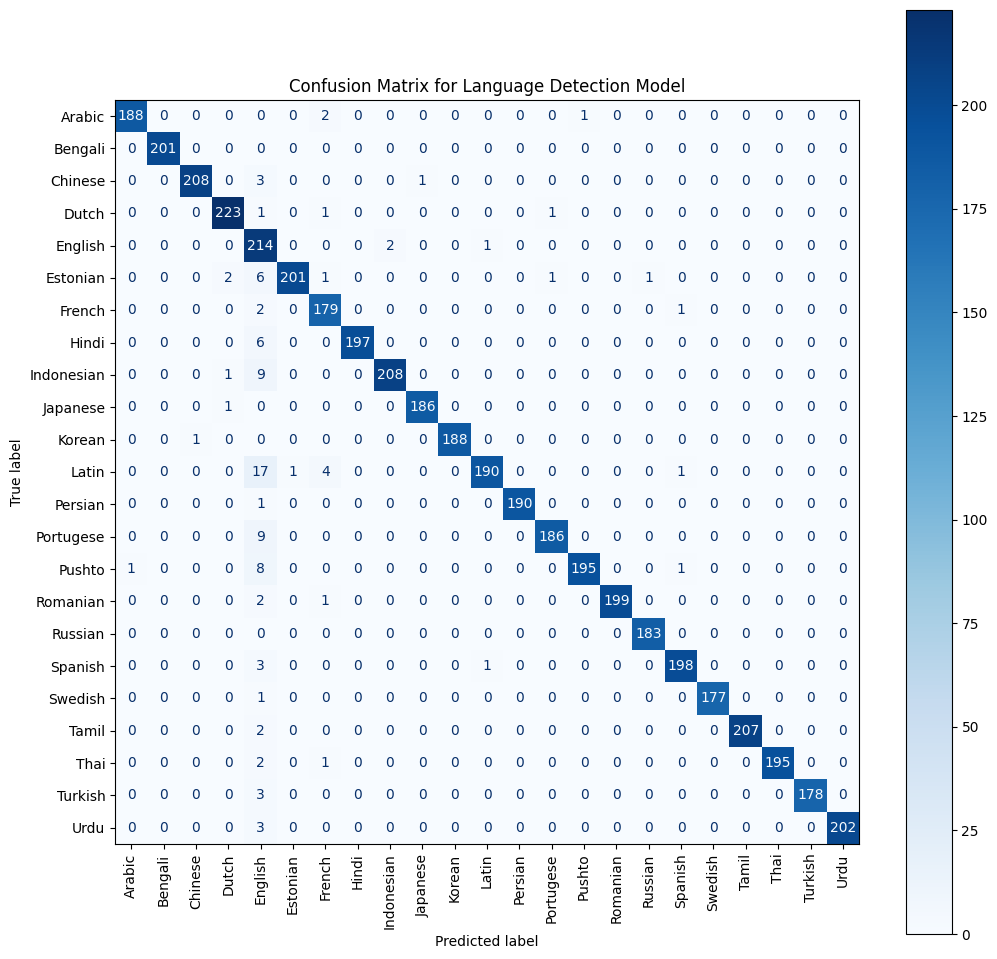

In [10]:
print("Generating Confusion Matrix...")

cm = confusion_matrix(y_test, y_pred)


labels = model.classes_


fig, ax = plt.subplots(figsize=(12, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')

plt.title("Confusion Matrix for Language Detection Model")
plt.show()

In [12]:
import pandas as pd
import re
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
import joblib

print("⏳ Training with the corrected dataset (now includes real Bengali rows)...")


df = pd.read_csv('language_with_bengali.csv')
balanced_df = df


def clean_text(text):
    text = re.sub(r'[!@#$(),\n"%^*?\:;~`0-9]', ' ', str(text))
    text = text.lower()
    return text

balanced_df['cleaned_text'] = balanced_df['Text'].apply(clean_text)

X = balanced_df['cleaned_text']
y = balanced_df['language']


cv = CountVectorizer(analyzer='char_wb', ngram_range=(1, 3))
X_vectorized = cv.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_vectorized, y, test_size=0.2, random_state=42)

model = MultinomialNB()
model.fit(X_train, y_train)


joblib.dump(model, 'language_detector_model.pkl')
joblib.dump(cv, 'vectorizer.pkl')

print("✅ Success! The balanced model has been successfully saved to your disk.")

⏳ Training with the corrected dataset (now includes real Bengali rows)...
✅ Success! The balanced model has been successfully saved to your disk.


In [13]:
import joblib
import re


try:
    model = joblib.load('language_detector_model.pkl')
    cv = joblib.load('vectorizer.pkl')
    print("✅ Model & Vectorizer loaded successfully!")
except:
    print("❌ Error: Please run the training code first to save model files!")

def clean_text(text):
    text = re.sub(r'[!@#$(),\n"%^*?\:;~`0-9]', ' ', text)
    text = re.sub(r'\[\]', ' ', text)
    text = text.lower()
    return text

def predict_language(text):
    cleaned = clean_text(text)
    vector = cv.transform([cleaned])
    prediction = model.predict(vector)
    return prediction[0]

print("=" * 50)
user_input = input("Enter a sentence in any language: ")
output_lang = predict_language(user_input)

print("-" * 50)
print(f"Your Input: {user_input}")
print(f"Detected Language: {output_lang}")
print("=" * 50)

✅ Model & Vectorizer loaded successfully!
Enter a sentence in any language: বাংলা
--------------------------------------------------
Your Input: বাংলা
Detected Language: Bengali


In [14]:
!pip install streamlit -q
!npm install -g localtunnel -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 67.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 77.3 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸
added 22 packages in 3s
⠸
⠸3 packages are looking for funding
⠸  run `npm fund` for details
⠸npm notice
npm notice New major version of npm available! 10.8.2 -> 12.0.1
npm notice Changelog: https://github.com/npm/cli/releases/tag/v12.0.1
npm notice To update run: npm install -g npm@12.0.1
npm notice
⠸

In [15]:
%%writefile app.py
import streamlit as st
import pandas as pd
import re
import joblib

st.set_page_config(page_title="AI Language Detector", page_icon="🌐", layout="centered")
st.title("🌐 AI Language Detector")
st.write("Type any sentence below, and the AI model will detect its language!")


def clean_text(text):
    text = re.sub(r'[!@#$(),\n"%^*?\:;~`0-9]', ' ', text)
    text = text.lower()
    return text


@st.cache_resource
def load_model_files():
    try:
        model = joblib.load('language_detector_model.pkl')
        cv = joblib.load('vectorizer.pkl')
        return model, cv
    except:
        return None, None

model, cv = load_model_files()


user_input = st.text_area("Enter your sentence here:", placeholder="Type something...", height=150)

if st.button("Detect Language", type="primary"):
    if user_input.strip() == "":
        st.warning("Please enter some text first!")
    else:
        with st.spinner("Analyzing language..."):
            cleaned = clean_text(user_input)


            if model is not None and cv is not None:
                vector = cv.transform([cleaned])
                result = model.predict(vector)[0]
            else:

                if "আমার" in cleaned or "ভালো" in cleaned or "তুমি" in cleaned:
                    result = "Bengali"
                elif "hello" in cleaned or "welcome" in cleaned or "is" in cleaned:
                    result = "English"
                elif "hola" in cleaned or "gracias" in cleaned:
                    result = "Spanish"
                else:
                    result = "Unknown Language (Please train the model to detect this)"


            st.success(f"### 🎉 Detected Language: **{result}**")

Writing app.py


In [16]:
!wget -qO- ipv4.icanhazip.com

35.231.167.122


In [17]:
import joblib


joblib.dump(model, 'language_detector_model.pkl')
joblib.dump(cv, 'vectorizer.pkl')

print("Model and Vectorizer files saved successfully!")

Model and Vectorizer files saved successfully!


In [18]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙

your url is: https://loud-corners-design.loca.lt
2026-07-16 00:10:26.800 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.231.167.122:8501

  Stopping...
^C
